# Regular TransE

In [187]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import random

from collections import defaultdict
import re
import json
import time
import requests
from datetime import datetime
import ast

Import CPE

In [188]:
df_cpe = pd.read_csv("../preprocess/csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [189]:
df_cve = pd.read_csv("../preprocess/csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'../preprocess/csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [190]:
df_cwe = pd.read_csv("../preprocess/csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv("../preprocess/csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv("../preprocess/csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

In [191]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [192]:
#reproducible performance
num = 50
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [193]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
        

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

In [194]:
def get_nearest_neighbors(model, query_entity_id, candidate_entity_ids, n=5):
    with torch.no_grad():
        entity_embs = model.entity_embeddings.weight 
        query_emb = entity_embs[query_entity_id]  

        #convert to tensor
        if not isinstance(candidate_entity_ids, torch.Tensor):
            candidate_entity_ids = torch.tensor(candidate_entity_ids, device=entity_embs.device)

        candidate_embs = entity_embs[candidate_entity_ids] 

        # L2 distances
        distances = torch.norm(candidate_embs - query_emb, p=2, dim=1)
        topk_vals, topk_indices = torch.topk(distances, k=n, largest=False)
        neighbors = [int(candidate_entity_ids[i]) for i in topk_indices]
        neighbors = [id2entity[ent] for ent in neighbors]
        return neighbors


Load Model for Evaluation

In [246]:
ex = "_other3"

#ex=""
with open(f"../threat_kg/id_conversions{ex}/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open(f"../threat_kg/id_conversions{ex}/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open(f"../threat_kg/id_conversions{ex}/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open(f"../threat_kg/id_conversions{ex}/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load(f"../threat_kg/id_conversions{ex}/triples_id.npy")

In [247]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("../threat_kg/models/transe_model_nll_other3.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(262321, 100)
  (relation_embeddings): Embedding(19, 100)
)

In [248]:
cwe_list = df_cwe['ID'].values.tolist()

In [249]:
#used for evaluation
def mr_score(ranks):
    return np.mean(ranks)


def mrr_score(ranks):
    return np.mean([1.0 / rank for rank in ranks])


def hits_at_n(ranks, n):
    return np.mean([rank <= n for rank in ranks])

In [250]:
df_cwe_1003 = pd.read_csv("../FixV2W/files/cwe-1003.csv", usecols=['CWE-ID', 'Weakness Abstraction'], index_col=False)
df_cwe_1003.fillna('*', inplace=True)
cwe_rels = pd.read_csv("../FixV2W/files/cwe_relations.csv")

cwe_sublist = []  # does not contain discouraged cwe from cwe-1003 list
cwe_1003 = []
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834", "CWE-284", "CWE-285", "CWE-287",
            "CWE-693", "CWE-788"]
for i, r in df_cwe_1003.iterrows():
    cweid = 'CWE-' + str(r['CWE-ID'])
    cwe_abs = r['Weakness Abstraction']
    cwe_1003.append(cweid)

    if cweid not in cwe_disc:
        cwe_sublist.append((cweid, cwe_abs))


In [251]:
cwe_dict = {}
for i, row in cwe_rels.iterrows():
    child = row['Child']
    parent = row['Parent']
    rel = row['Relationship']

    if rel == 'ChildOf':
        if child in cwe_dict:
            cwe_dict[child].append(parent)
        else:
            cwe_dict[child] = []
            cwe_dict[child].append(parent)

In [252]:
# this is similar to the query_topn() function we use in ampligraph
def query_topn(model, head_id, relation_id, candidate_tail_ids, top_n=10):
    model.eval()
    with torch.no_grad():
        # create copies of head and relation entities for all tail entities to query
        h = torch.tensor([head_id], device=device).long().repeat(len(candidate_tail_ids))
        r = torch.tensor([relation_id], device=device).long().repeat(len(candidate_tail_ids))
        t = torch.tensor(candidate_tail_ids, device=device).long()

        triples = torch.stack([h, r, t], dim=1)  # Shape: (num_candidates, 3)
        scores = model.predict(triples)         # Shape: (num_candidates,)

        sorted_scores, indices = torch.sort(scores, descending=True)  # larger scores are better
        sorted_tail_ids = [candidate_tail_ids[i] for i in indices.cpu().numpy()]
        sorted_scores = sorted_scores.cpu().numpy()

        # Return top N (or fewer if not enough candidates)
        return sorted_tail_ids[:top_n], sorted_scores[:top_n]

In [253]:
def get_sib_fam(cwe):
    family = []
    if cwe in cwe_dict:
        parents = cwe_dict[cwe]
        for p in parents:
            family.extend(get_cwe_children(p))
    return list(set(family)-{cwe})

In [254]:
# This is the first method I implemented to find family of the CWE. Usually, this yields a 
# large list of CWE that are related to each other, since we are returning the whole branch
# that CWE is in. Rather, we can also just return direct parents and children (below cell)

def get_cwe_parents(cwe):
    # given a cwe, find all related cwe that are in the same branch.
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
            res = get_cwe_parents(item)  # recursively reach branch head and all 'grandparents'
            if res:
                family.extend(res)
    return family


def get_cwe_children(cwe):
    family = []
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        family.extend(keys)
        for item in keys:
            res = get_cwe_children(item)  
            if res:
                family.extend(res)
    return family


def get_cwe_family(cwe):
    return set(get_cwe_parents(cwe) + get_cwe_children(cwe))

In [255]:
def strtoList(string):
    ret = []
    arr = string.split("'")
    for i in arr:
        if len(i)>3:
            ret.append(i)
    return ret

In [256]:
# For the fine-grain analysis, we need only immediate family - direct children and parents
def get_direct_family(cwe):
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        #print(keys)
        family.extend(keys)
    return family

In [257]:
# using df_cwe_cate or df_cwe_view for querying for CWEs in that list (that can be used to map CVEs i.e. in CWE-1003 list)
def get_cwe_subtree(cweid):
    cwe_members = []
    
    if cweid in df_cwe_cate['ID'].tolist():    
        item = df_cwe_cate.loc[df_cwe_cate['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
        
    elif cweid in df_cwe_view['ID'].tolist():  
        item = df_cwe_view.loc[df_cwe_view['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
    
    cwe_ret = []
    if cwe_members:
        for item in cwe_members[0]:
            if item in cwe_1003 and item not in cwe_ret:
                cwe_ret.append(item)

            #optionally comment out this for loop to avoid overcrowding the candidate list
            family = get_cwe_family(item)
            for x in family:
                if x in cwe_1003 and x not in cwe_ret:
                    cwe_ret.append(x)
    return cwe_ret

In [258]:
def extract_cwes_from_string(s):
    import re
    if not isinstance(s, str):
        return []
    # Find all CWE patterns like 'CWE-920'
    cwes = re.findall(r'CWE-\d+', s)
    return cwes

In [259]:
df_d = pd.read_csv('../FixV2W/files/new_filtered_query_d.csv')
df_p = pd.read_csv('../FixV2W/files/new_filtered_query_p.csv')

In [260]:
top25 = pd.read_csv('../FixV2W/files/cwe_top25.csv')['ID'].values.tolist()
top25_ids = [entity2id[cwe] for cwe in top25 if cwe in entity2id]
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

Other/Noinfo set

In [261]:
def get_1003_sublist(items):
    res = []
    for item in items:
        if item in cwe_1003 and item not in res:
            res.append(item)
    return res

In [262]:
other_q = pd.read_csv('files/other_query_d.csv')
other_q["cwe_aft"] = other_q["cwe_aft"].apply(ast.literal_eval)

In [263]:
df = pd.read_csv('files/other_query_d.csv')

# safely parse the stringified lists in column 3
df["cwe_aft"] = df["cwe_aft"].apply(ast.literal_eval)

# make dictionary: {cve: cwe_aft_list}
cve_to_cwe = dict(zip(df["cve"], df["cwe_aft"]))
cve_to_cwe['CVE-2017-15944'] = ['CWE-20', 'CWE-119']

In [264]:
df_cwe = pd.read_csv("../preprocess/csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv("../preprocess/csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv("../preprocess/csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

new_cve_df = pd.read_csv('../FixV2W/files/cve2cwe_2024.csv')
df_cve2cwe = pd.read_csv('../FixV2W/files/df_cve2cwe.csv')
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

In [265]:
results = {}

rel_id = relation2id['MatchingCWE']
for i, pair in tqdm(other_q.iterrows(), total=len(other_q)):
    cwe_q = pair['cwe_bef']
    disc = 0
    proh = 0
    cve_q = pair['cve']
    if cwe_q in cwe_disc:
        disc += 1
    if cwe_q in cwe_prohibited:
        proh += 1
    # if disc:
    #     cwe_to_query = get_1003_sublist(get_cwe_children(cwe_q))
    #     if len(cwe_to_query) < 10:
    #         cwe_to_query = get_1003_sublist(get_sib_fam(cwe_q))
    # elif proh:
    #     cwe_to_query = get_cwe_subtree(cwe_q)
    # else:
    #     cwe_to_query = cwe_1003
    cwe_to_query = cwe_1003
    candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != cwe_q]
    candidate_tail_ids = list(set(candidate_tail_ids))
    for cve in strtoList(cve_q):
        
        try:
            head_id = entity2id[cve]
            res = query_topn(model, head_id, rel_id, candidate_tail_ids)
            results[cve] = [res, cwe_q]
        except:
            pass

  0%|          | 0/229 [00:00<?, ?it/s]

In [266]:
total = 0
count = 0
match_indices = []  # store the rank (index) where a correct prediction occurred
fine_grain = []
coarse_grain = []
cwe1003num = 0
for cve, preds in results.items():
    flat_preds = [id2entity[cwe] for cwe in preds[0][0] if cwe in id2entity]
    true_cwes = cve_to_cwe.get(cve, [])
    for w in true_cwes:
        if w in cwe_1003:
            cwe1003num += 1

    matched = False
    for idx, p in enumerate(flat_preds):
        if p in true_cwes:
            count += 1
            match_indices.append(idx+1)
            matched = True
            break  # stop at first correct match
    if not matched:
        fine_grain_fam = []
        coarse_fam = []
        for w in true_cwes:
            fine_grain_fam.extend(get_direct_family(w))
            coarse_fam.extend(get_cwe_family(w))
        for idx, p in enumerate(flat_preds):
            if p in fine_grain_fam:
                count += 1
                fine_grain.append(idx+1)
                matched = True
                break 
    if not matched:
        for idx, p in enumerate(flat_preds):
            if p in coarse_fam:
                count += 1
                coarse_grain.append(idx+1)
                matched = True
                break 
            
    
    total += 1

accuracy = count / total if total > 0 else 0
avg_rank = sum(match_indices) / len(match_indices) if match_indices else None

print(f"Matched {count} out of {total} CVEs ({accuracy:.3%})")
if avg_rank is not None:
    print(f"Average match index: {avg_rank:.2f}")
else:
    print("No matches found.")


Matched 70 out of 176 CVEs (39.773%)
Average match index: 4.86


In [267]:
print(len(match_indices), len(fine_grain), len(coarse_grain), total-count) 

37 25 8 106


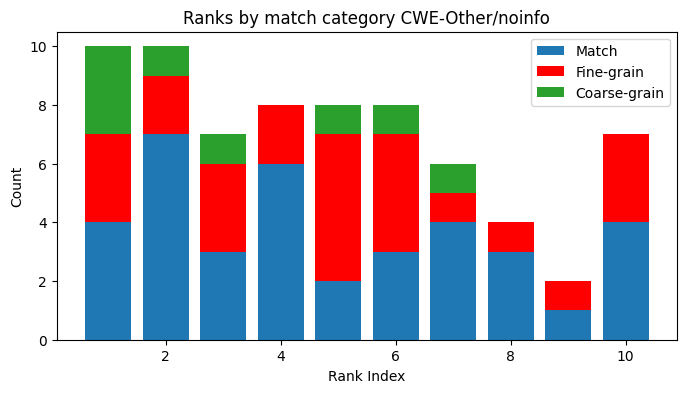

In [268]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

match_counts = Counter(match_indices)
fine_counts = Counter(fine_grain)
coarse_counts = Counter(coarse_grain)

# All possible indices (ranks)
all_ranks = sorted(set(match_counts) | set(fine_counts) | set(coarse_counts))

# Get aligned counts
match_vals = np.array([match_counts.get(r, 0) for r in all_ranks])
fine_vals = np.array([fine_counts.get(r, 0) for r in all_ranks])
coarse_vals = np.array([coarse_counts.get(r, 0) for r in all_ranks])

# Plot stacked bars
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(all_ranks, match_vals, color='tab:blue', label='Match')
ax.bar(all_ranks, fine_vals, bottom=match_vals, color='red', label='Fine-grain')
ax.bar(all_ranks, coarse_vals, bottom=match_vals + fine_vals, color='tab:green', label='Coarse-grain')

ax.set_xlabel("Rank Index")
ax.set_ylabel("Count")
ax.set_title("Ranks by match category CWE-Other/noinfo")
ax.legend()
plt.show()


### Prohibited set

In [269]:
df_cwe = pd.read_csv("../preprocess/csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv("../preprocess/csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv("../preprocess/csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

new_cve_df = pd.read_csv('../FixV2W/files/cve2cwe_2024.csv')
df_cve2cwe = pd.read_csv('../FixV2W/files/df_cve2cwe.csv')
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

The code below runs the queries. We can experiment with the ```cwe_to_query``` variable to test different candidate sets.

In [270]:
results = {}
rel_id = relation2id['MatchingCWE']
total = 0
start = time.time()
for i, pair in tqdm(df_p.iterrows(), total=len(df_p)):
    cwe_q = pair['CWE']
    cve_q = pair['CVE']
    cwe_to_query = get_cwe_subtree(cwe_q)
    if cwe_q == 'CWE-17':
        continue
        
    if len(cwe_to_query) == 0:
        #use nearest neighbors if no subtree members are found
        # cwe_1003_id = [entity2id[cwe] for cwe in cwe_1003 if cwe != cwe_q]
        # cwe_to_query = get_nearest_neighbors(model, entity2id[cwe_q], cwe_1003_id, n=10)
        print(cwe_q)
        #use cwe-1003 list if not subtree members are found
        cwe_to_query = [cwe for cwe in cwe_1003 if cwe != cwe_q]
    
    candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != cwe_q]
    for cve in strtoList(cve_q):
        head_id = entity2id[cve]
        try:
            res = query_topn(model, head_id, rel_id, candidate_tail_ids)
            results[cve] = [res, cwe_q]          
        except:
            pass
        total +=1
end = time.time()
elap = end - start
print('Total queries made: ', total)
print(elap)
print(elap/total)

  0%|          | 0/11 [00:00<?, ?it/s]

CWE-16
CWE-264
Total queries made:  337
0.22554874420166016
0.000669284107423324


In [271]:
data = []

for cve, (predictions, old_cwe) in results.items():
    rank_labels = [id2entity[pred] for pred in predictions[0]]
    scores = predictions[1]

    data.append({
        'CVE': cve,
        'Rank': rank_labels,
        'Score': scores,
        'Old CWE': old_cwe
    })

df_res = pd.DataFrame(data)
df_res.to_csv('cwe_proh_query.csv', index=False)

In [272]:
results_df_proh = pd.read_csv('cwe_proh_query.csv', names=["CVE", "Result", "Score", 'Old CWE'], skiprows=1)

In [273]:
cwe_cve_p = []

for i, pair in df_p.iterrows():
    cwe_q = pair['CWE']
    cve_q = pair['CVE']

    for cve in strtoList(cve_q):
        new_cve = new_cve_df.loc[new_cve_df["subject:START_ID"] == cve]
        new_cwe = new_cve['object:END_ID'].values
        
        old_cve = df_cve2cwe[df_cve2cwe["CVE"]==cve]
        old_cwe = old_cve['CWE'].values
        
        #print(new_cwe, old_cwe)
        for item in new_cwe:
            if item not in old_cwe: # added this to avoid evaluating for already existing CWE mappings prior to validation
                cwe_cve_p.append((cwe_q, cve, item))
        
df_compare_p = pd.DataFrame(cwe_cve_p, columns=['OldCWE', 'CVE', 'CWE-NVD']) #,'CWE-KG'])
df_compare_p['CWE-KG'] = None

In [274]:
for item in cwe_cve_p:
    cve = item[1]
    row_d = df_compare_p.loc[df_compare_p['CVE']==cve]
    
    row = results_df_proh.loc[results_df_proh['CVE']==cve]
    if not row.empty:
        cwe_ranked = row["Result"].apply(ast.literal_eval).values[0]
        df_compare_p.loc[df_compare_p['CVE']==cve,'CWE-KG'] = str(cwe_ranked)

In [275]:
not_found = 0

exact_match = []
fine_grain = []
coarse_grain = []
other_cve = []

for index, row in df_compare_p.iterrows():
    cve = row["CVE"]
    
    oldCWE = row["OldCWE"]
    newCWE = row["CWE-NVD"]
    try:
        kg_list = ast.literal_eval(row["CWE-KG"])
    except ValueError:
        kg_list = []
    match = False
        
    
    if newCWE in kg_list:
        match = True
        rank = kg_list.index(newCWE) + 1
        exact_match.append((cve, newCWE, rank))
    
    else:
        fam = get_direct_family(newCWE)
        fam_all = get_cwe_family(newCWE)
        for result in kg_list:
            if result in fam:
                
                match = True
                rank = kg_list.index(result) + 1
                fine_grain.append((cve, result, rank))
                break

        if not match:
            for result in kg_list:
                if result in fam_all:
                    match = True
                    rank = kg_list.index(result) + 1
                    coarse_grain.append((cve, result, rank))
                    break
    if not match:
        not_found +=1
        other_cve.append((cve, newCWE))

In [276]:
print("Number of exact matches:", len(exact_match))
print("Number of fine-grain matches:", len(fine_grain))
print("Number of coarse-grain matches:", len(coarse_grain))
print("Number of mappings not predicted:", not_found)

Number of exact matches: 169
Number of fine-grain matches: 29
Number of coarse-grain matches: 44
Number of mappings not predicted: 97


In [277]:
df = pd.DataFrame(exact_match, columns=['CVE', 'CWE', 'Rank'])
df_fine = pd.DataFrame(fine_grain, columns=['CVE', 'CWE', 'Rank'])
df_coarse = pd.DataFrame(coarse_grain, columns=['CVE', 'CWE', 'Rank'])


df['MatchType'] = 'Exact'
df_fine['MatchType'] = 'Fine'
df_coarse['MatchType'] = 'Coarse'

overall_df_p = pd.concat([df, df_fine, df_coarse], ignore_index=True)

In [278]:
overall_df_p.to_csv('proh_query_res.csv', index = False)

In [279]:
ranks = df['Rank'].values.tolist()
ranks_fine = df_fine['Rank'].values.tolist()
ranks_coarse = df_coarse['Rank'].values.tolist()

In [280]:
def get_metrics(ranks):
    mr = mr_score(ranks)
    mrr = mrr_score(ranks)
    hits_at_1 = hits_at_n(ranks, 1)
    hits_at_3 = hits_at_n(ranks, 3)
    hits_at_5 = hits_at_n(ranks, 5)
    print('Mean Rank:', mr)
    print('Mean Reciprocal Rank:', mrr)
    print("Hits@1:", hits_at_1) 
    print("Hits@3:", hits_at_3)  
    print("Hits@5:", hits_at_5)

Evaluation Metrics for exact, fine, and coarse grain matches for Prohibited set

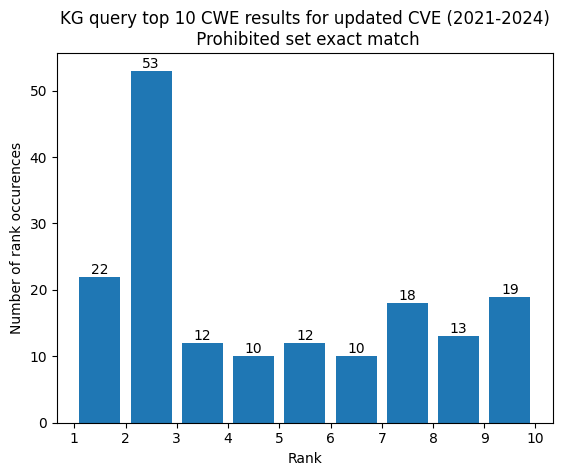

Mean Rank: 4.337278106508876
Mean Reciprocal Rank: 0.3863036536113459
Hits@1: 0.1301775147928994
Hits@3: 0.514792899408284
Hits@5: 0.6449704142011834


In [281]:
bins = np.arange(1, 11)
counts, edges, bars = plt.hist(ranks, rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set exact match")
plt.xticks(bins)
plt.show()
get_metrics(ranks)

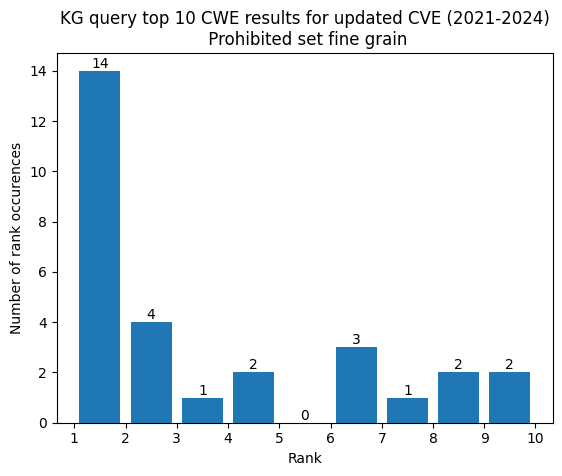

Mean Rank: 3.1724137931034484
Mean Reciprocal Rank: 0.6189107827038861
Hits@1: 0.4827586206896552
Hits@3: 0.6551724137931034
Hits@5: 0.7241379310344828


In [282]:
counts, edges, bars = plt.hist(ranks_fine,rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set fine grain")
plt.xticks(bins)
plt.show()
get_metrics(ranks_fine) 

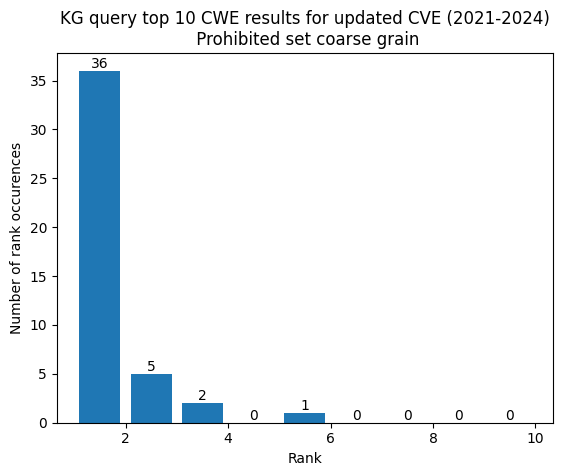

Mean Rank: 1.2954545454545454
Mean Reciprocal Rank: 0.8946969696969695
Hits@1: 0.8181818181818182
Hits@3: 0.9772727272727273
Hits@5: 1.0


In [283]:
counts, edges, bars = plt.hist(ranks_coarse,rwidth=0.8, bins = np.arange(1, 11))
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set coarse grain")
plt.show()
get_metrics(ranks_coarse)  

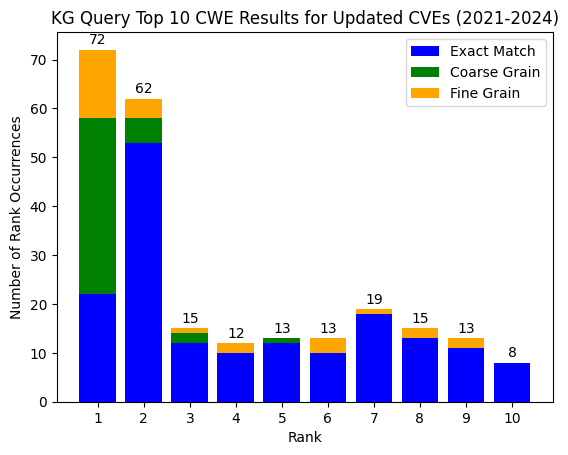

Mean Rank: 3.644628099173554
Mean Reciprocal Rank: 0.506613210022301
Hits@1: 0.2975206611570248
Hits@3: 0.6157024793388429
Hits@5: 0.71900826446281


In [284]:
def plot_breakdown(ranks, ranks2, ranks3, topn):
    bins = np.arange(1, topn+1)
    hist1 = [ranks.count(b) for b in bins]
    hist2 = [ranks3.count(b) for b in bins]
    hist4 = [ranks2.count(b) for b in bins]
    
    total_heights = np.array(hist1) + np.array(hist2) + np.array(hist4)
    
    bar_width = 0.8
    plt.figure()
    bar1 = plt.bar(bins, hist1, width=bar_width, label='Exact Match', color='blue')
    bar2 = plt.bar(bins, hist2, width=bar_width, bottom=hist1, label='Coarse Grain', color='green')
    bar3 = plt.bar(bins, hist4, width=bar_width, bottom=np.array(hist1)+np.array(hist2), label='Fine Grain', color='orange')
    # Add total count on top of each bar
    for i, total in enumerate(total_heights):
        plt.text(bins[i], total + 0.5, str(total), ha='center', va="bottom")

    # Labels and legend
    plt.xlabel("Rank")
    plt.ylabel("Number of Rank Occurrences")
    plt.title("KG Query Top 10 CWE Results for Updated CVEs (2021-2024)")
    plt.xticks(bins)
    plt.legend()
    plt.show()


plot_breakdown(ranks, ranks_fine, ranks_coarse, 10)
get_metrics(ranks+ranks_fine+ranks_coarse)

### Discouraged Set

In [285]:
def get_1003_sublist(items):
    res = []
    for item in items:
        if item in cwe_1003 and item not in res:
            res.append(item)
    return res

In [286]:
results = {}
rel_id = relation2id['MatchingCWE']
total = 0
start = time.time()
for i, pair in tqdm(df_d.iterrows(), total=len(df_d)):
    cwe_q = pair['CWE']
    cve_q = pair['CVE']
    cwe_to_query = get_1003_sublist(get_cwe_children(cwe_q))
    if len(cwe_to_query) < 10:
        cwe_to_query = get_1003_sublist(get_sib_fam(cwe_q))
    if len(cwe_to_query) == 0:
        print(cwe_q)
        cwe_to_query = [cwe for cwe in cwe_1003 if cwe != cwe_q]
    candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != cwe_q]
    candidate_tail_ids = list(set(candidate_tail_ids))
    for cve in strtoList(cve_q):
        head_id = entity2id[cve]
        try:
            res = query_topn(model, head_id, rel_id, candidate_tail_ids)
            results[cve] = [res, cwe_q]
        except:
            pass
        total += 1
end = time.time()
elap = end - start
print(elap)
print(total)
print(elap/total)

  0%|          | 0/21 [00:00<?, ?it/s]

CWE-682
CWE-697
0.9708685874938965
1467
0.0006618054447811155


In [287]:
data = []

for cve, (predictions, old_cwe) in results.items():
    rank_labels = [id2entity[pred] for pred in predictions[0]]
    scores = predictions[1]

    data.append({
        'CVE': cve,
        'Rank': rank_labels,
        'Score': scores,
        'Old CWE': old_cwe
    })

df_res = pd.DataFrame(data)
df_res.to_csv('cwe_disc_query.csv', index=False)

In [288]:
results_df_disc = pd.read_csv('cwe_disc_query.csv', names=["CVE", "Result", "Score", 'Old CWE'], skiprows=1)

In [289]:
cwe_cve_d = []

for i, pair in df_d.iterrows():
    cwe_q = pair['CWE']
    cve_q = pair['CVE']

    for cve in strtoList(cve_q):
        new_cve = new_cve_df.loc[new_cve_df["subject:START_ID"] == cve]
        new_cwe = new_cve['object:END_ID'].values
        
        old_cve = df_cve2cwe[df_cve2cwe["CVE"]==cve]
        old_cwe = old_cve['CWE'].values
        
        #print(new_cwe, old_cwe)
        for item in new_cwe:
            if item not in old_cwe: # added this to avoid evaluating for already existing CWE mappings prior to validation
                cwe_cve_d.append((cwe_q, cve, item))
        
df_compare_d = pd.DataFrame(cwe_cve_d, columns=['OldCWE', 'CVE', 'CWE-NVD']) #,'CWE-KG'])
df_compare_d['CWE-KG'] = None

In [290]:
for item in cwe_cve_d:
    cve = item[1]
    row_d = df_compare_d.loc[df_compare_d['CVE']==cve]
    
    row = results_df_disc.loc[results_df_disc['CVE']==cve]
    if not row.empty:
        cwe_ranked = row["Result"].apply(ast.literal_eval).values[0]
        df_compare_d.loc[df_compare_d['CVE']==cve,'CWE-KG'] = str(cwe_ranked)

In [291]:
not_found = 0

exact_match = []
fine_grain = []
coarse_grain = []
other_cve = []

for index, row in df_compare_d.iterrows():
    cve = row["CVE"]
    
    oldCWE = row["OldCWE"]
    newCWE = row["CWE-NVD"]
    kg_str = row["CWE-KG"].replace("'", "")[1:-1]

    kg_list = kg_str.split(', ')    
    match = False
    
    if newCWE in kg_list:
        match = True
        rank = kg_list.index(newCWE) + 1
        exact_match.append((cve, newCWE, rank))
    
    else:
        fam = get_direct_family(newCWE)
        fam_all = get_cwe_family(newCWE)
        for result in kg_list:

            if result in fam:
                match = True
                rank = kg_list.index(result) + 1
                fine_grain.append((cve, result, rank))
                break

        if not match:
            for result in kg_list:
                if result in fam_all:
                    match = True
                    rank = kg_list.index(result) + 1
                    coarse_grain.append((cve, result, rank))
                    break
    if not match:
        not_found +=1
        other_cve.append((cve, newCWE))

In [292]:
print("Number of exact matches:", len(exact_match))
print("Number of fine-grain matches:", len(fine_grain))
print("Number of coarse-grain matches:", len(coarse_grain))
print("Number of mappings not predicted:", not_found)

Number of exact matches: 813
Number of fine-grain matches: 82
Number of coarse-grain matches: 4
Number of mappings not predicted: 581


In [293]:
df = pd.DataFrame(exact_match, columns=['CVE', 'CWE', 'Rank'])
df_fine = pd.DataFrame(fine_grain, columns=['CVE', 'CWE', 'Rank'])
df_coarse = pd.DataFrame(coarse_grain, columns=['CVE', 'CWE', 'Rank'])

df['MatchType'] = 'Exact'
df_fine['MatchType'] = 'Fine'
df_coarse['MatchType'] = 'Coarse'

overall_df_d = pd.concat([df, df_fine, df_coarse], ignore_index=True)


In [294]:
overall_df_d.to_csv('disc_query_res.csv', index=False)

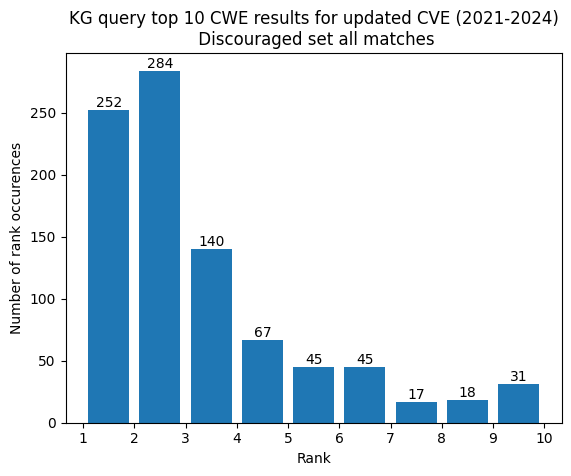

Mean Rank: 2.843159065628476
Mean Reciprocal Rank: 0.5360594664265409
Hits@1: 0.2803114571746385
Hits@3: 0.7519466073414905
Hits@5: 0.8765294771968855


In [295]:
bins = np.arange(1, 11)
counts, edges, bars = plt.hist(overall_df_d['Rank'].values.tolist(), rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set all matches")
plt.xticks(bins)
plt.show()
get_metrics(overall_df_d['Rank'].values.tolist())

In [296]:
ranks = df['Rank'].values.tolist()
ranks_fine = df_fine['Rank'].values.tolist()
ranks_coarse = df_coarse['Rank'].values.tolist()

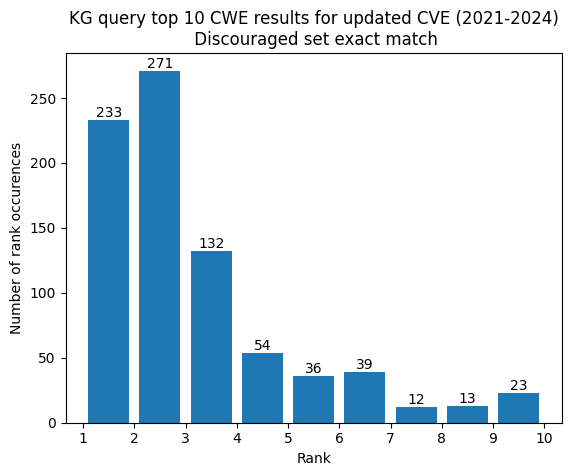

Mean Rank: 2.7121771217712176
Mean Reciprocal Rank: 0.5479641344032489
Hits@1: 0.2865928659286593
Hits@3: 0.7822878228782287
Hits@5: 0.8929889298892989


In [297]:
counts, edges, bars = plt.hist(ranks, rwidth=0.8, bins=np.arange(1,11))
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set exact match")
plt.xticks(np.arange(1, 11))
plt.show()
get_metrics(ranks) 

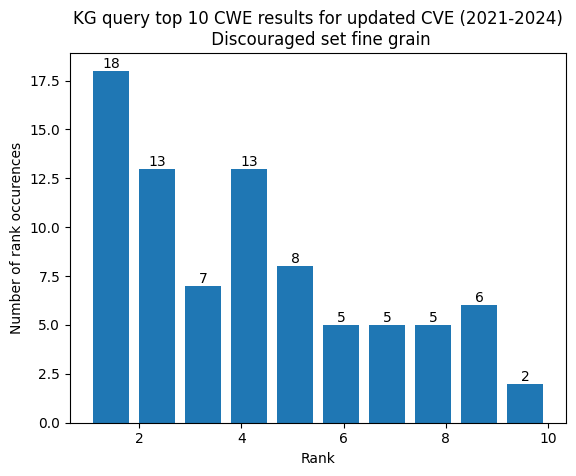

Mean Rank: 4.097560975609756
Mean Reciprocal Rank: 0.4234465737514518
Hits@1: 0.21951219512195122
Hits@3: 0.4634146341463415
Hits@5: 0.7195121951219512


In [298]:
counts, edges, bars = plt.hist(ranks_fine, rwidth=0.8)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set fine grain")
plt.show()
get_metrics(ranks_fine)  

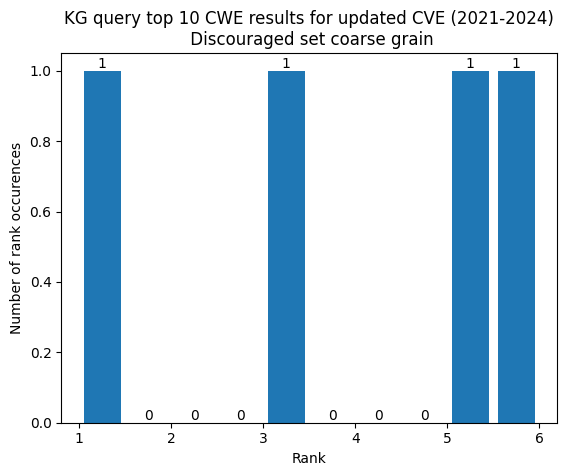

Mean Rank: 3.75
Mean Reciprocal Rank: 0.425
Hits@1: 0.25
Hits@3: 0.5
Hits@5: 0.75


In [299]:
counts, edges, bars = plt.hist(ranks_coarse, rwidth=0.8)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set coarse grain")
plt.show()
get_metrics(ranks_coarse)  

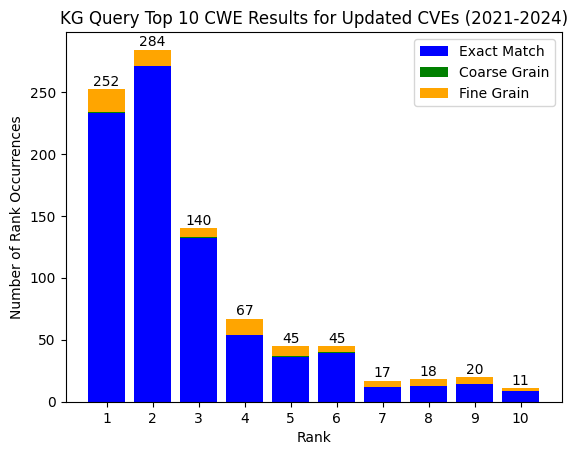

Mean Rank: 2.843159065628476
Mean Reciprocal Rank: 0.5360594664265409
Hits@1: 0.2803114571746385
Hits@3: 0.7519466073414905
Hits@5: 0.8765294771968855


In [300]:
plot_breakdown(ranks, ranks_fine, ranks_coarse, 10)
get_metrics(ranks+ranks_fine+ranks_coarse)